# Customer Intelligence System using Classification, Ensemble Learning & Clustering

## Problem Statement
Customer and country data contain valuable patterns that can support better decision-making. This project uses clustering to identify similar groups and classification models to predict these groups for new data.

## Objectives
- Analyze the dataset.
- Segment countries using K-Means and DBSCAN.
- Build Decision Tree, Random Forest, and XGBoost classifiers.
- Compare model performance.
- Generate actionable business insights.

## Real-World Applications
- Customer segmentation
- Market analysis
- Investment planning
- Business strategy
- Risk assessment

## Expected Outcomes
- Meaningful customer/country segments
- Accurate classification models
- Feature importance analysis
- Business recommendations

In [36]:
# ==========================================================
# Customer Intelligence System
# Author: Prince Atul
# Objective: Customer Segmentation & Classification
# ==========================================================

print("=" * 60)
print("Customer Intelligence System")
print("=" * 60)

print("\nAssignment Objectives:")
print("- Perform Exploratory Data Analysis (EDA)")
print("- Segment data using K-Means and DBSCAN")
print("- Build Decision Tree, Random Forest & XGBoost models")
print("- Evaluate model performance")
print("- Generate business insights")

print("\nStatus: Project Initialized Successfully")

Customer Intelligence System

Assignment Objectives:
- Perform Exploratory Data Analysis (EDA)
- Segment data using K-Means and DBSCAN
- Build Decision Tree, Random Forest & XGBoost models
- Evaluate model performance
- Generate business insights

Status: Project Initialized Successfully


# Import Libraries

The following libraries are used for data manipulation, visualization, clustering, classification, model evaluation, and feature scaling throughout the project.

In [37]:
!pip install -q xgboost

In [38]:
# ==========================================================
# Import Required Libraries
# ==========================================================

# Data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Data preprocessing
from sklearn.preprocessing import StandardScaler

# Clustering
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# Plot settings
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print(" All libraries imported successfully.")

 All libraries imported successfully.


# Load Dataset

Load the dataset and perform an initial inspection to understand its structure and quality before analysis.

In [39]:
# ==========================================================
# Load Dataset
# ==========================================================

# Load dataset
df = pd.read_csv("Country-data.csv")

print(" Dataset loaded successfully!")

# Display first 5 rows
display(df.head())

# Dataset shape
print(f"\nRows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

# Column names
print("\nColumns:")
print(df.columns.tolist())

# Data types
print("\nData Types:")
display(df.dtypes)

# Dataset information
print("\nDataset Information:")
df.info()

# Missing values
print("\nMissing Values:")
display(df.isnull().sum())

# Duplicate records
print(f"\nDuplicate Rows: {df.duplicated().sum()}")

# Statistical summary
print("\nSummary Statistics:")
display(df.describe().T)

 Dataset loaded successfully!


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200



Rows: 167
Columns: 10

Columns:
['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

Data Types:


,0
country,object
child_mort,float64
exports,float64
health,float64
imports,float64
income,int64
inflation,float64
life_expec,float64
total_fer,float64
gdpp,int64



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB

Missing Values:


,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0



Duplicate Rows: 0

Summary Statistics:


,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.270060,40.328931,2.6000,8.250,19.30,62.10,208.00
exports,167.0,41.108976,27.412010,0.1090,23.800,35.00,51.35,200.00
health,167.0,6.815689,2.746837,1.8100,4.920,6.32,8.60,17.90
imports,167.0,46.890215,24.209589,0.0659,30.200,43.30,58.75,174.00
income,167.0,17144.688623,19278.067698,609.0000,3355.000,9960.00,22800.00,125000.00
inflation,167.0,7.781832,10.570704,-4.2100,1.810,5.39,10.75,104.00
life_expec,167.0,70.555689,8.893172,32.1000,65.300,73.10,76.80,82.80
total_fer,167.0,2.947964,1.513848,1.1500,1.795,2.41,3.88,7.49
gdpp,167.0,12964.155689,18328.704809,231.0000,1330.000,4660.00,14050.00,105000.00


### Observations

- The dataset has **167 countries** with multiple socio-economic and health-related features.
- No missing values or duplicate records are expected.
- Features have different scales, so feature scaling will be required before clustering.

# Exploratory Data Analysis (EDA)

EDA helps understand the distribution of features, identify relationships, detect outliers, and gain insights before applying machine learning models.

In [40]:
# ==========================================================
# Summary Statistics
# ==========================================================

display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.270060,40.328931,2.6000,8.250,19.30,62.10,208.00
exports,167.0,41.108976,27.412010,0.1090,23.800,35.00,51.35,200.00
health,167.0,6.815689,2.746837,1.8100,4.920,6.32,8.60,17.90
imports,167.0,46.890215,24.209589,0.0659,30.200,43.30,58.75,174.00
income,167.0,17144.688623,19278.067698,609.0000,3355.000,9960.00,22800.00,125000.00
inflation,167.0,7.781832,10.570704,-4.2100,1.810,5.39,10.75,104.00
life_expec,167.0,70.555689,8.893172,32.1000,65.300,73.10,76.80,82.80
total_fer,167.0,2.947964,1.513848,1.1500,1.795,2.41,3.88,7.49
gdpp,167.0,12964.155689,18328.704809,231.0000,1330.000,4660.00,14050.00,105000.00


**Observation:** The dataset contains features with different value ranges, indicating that feature scaling will be necessary before clustering and classification.

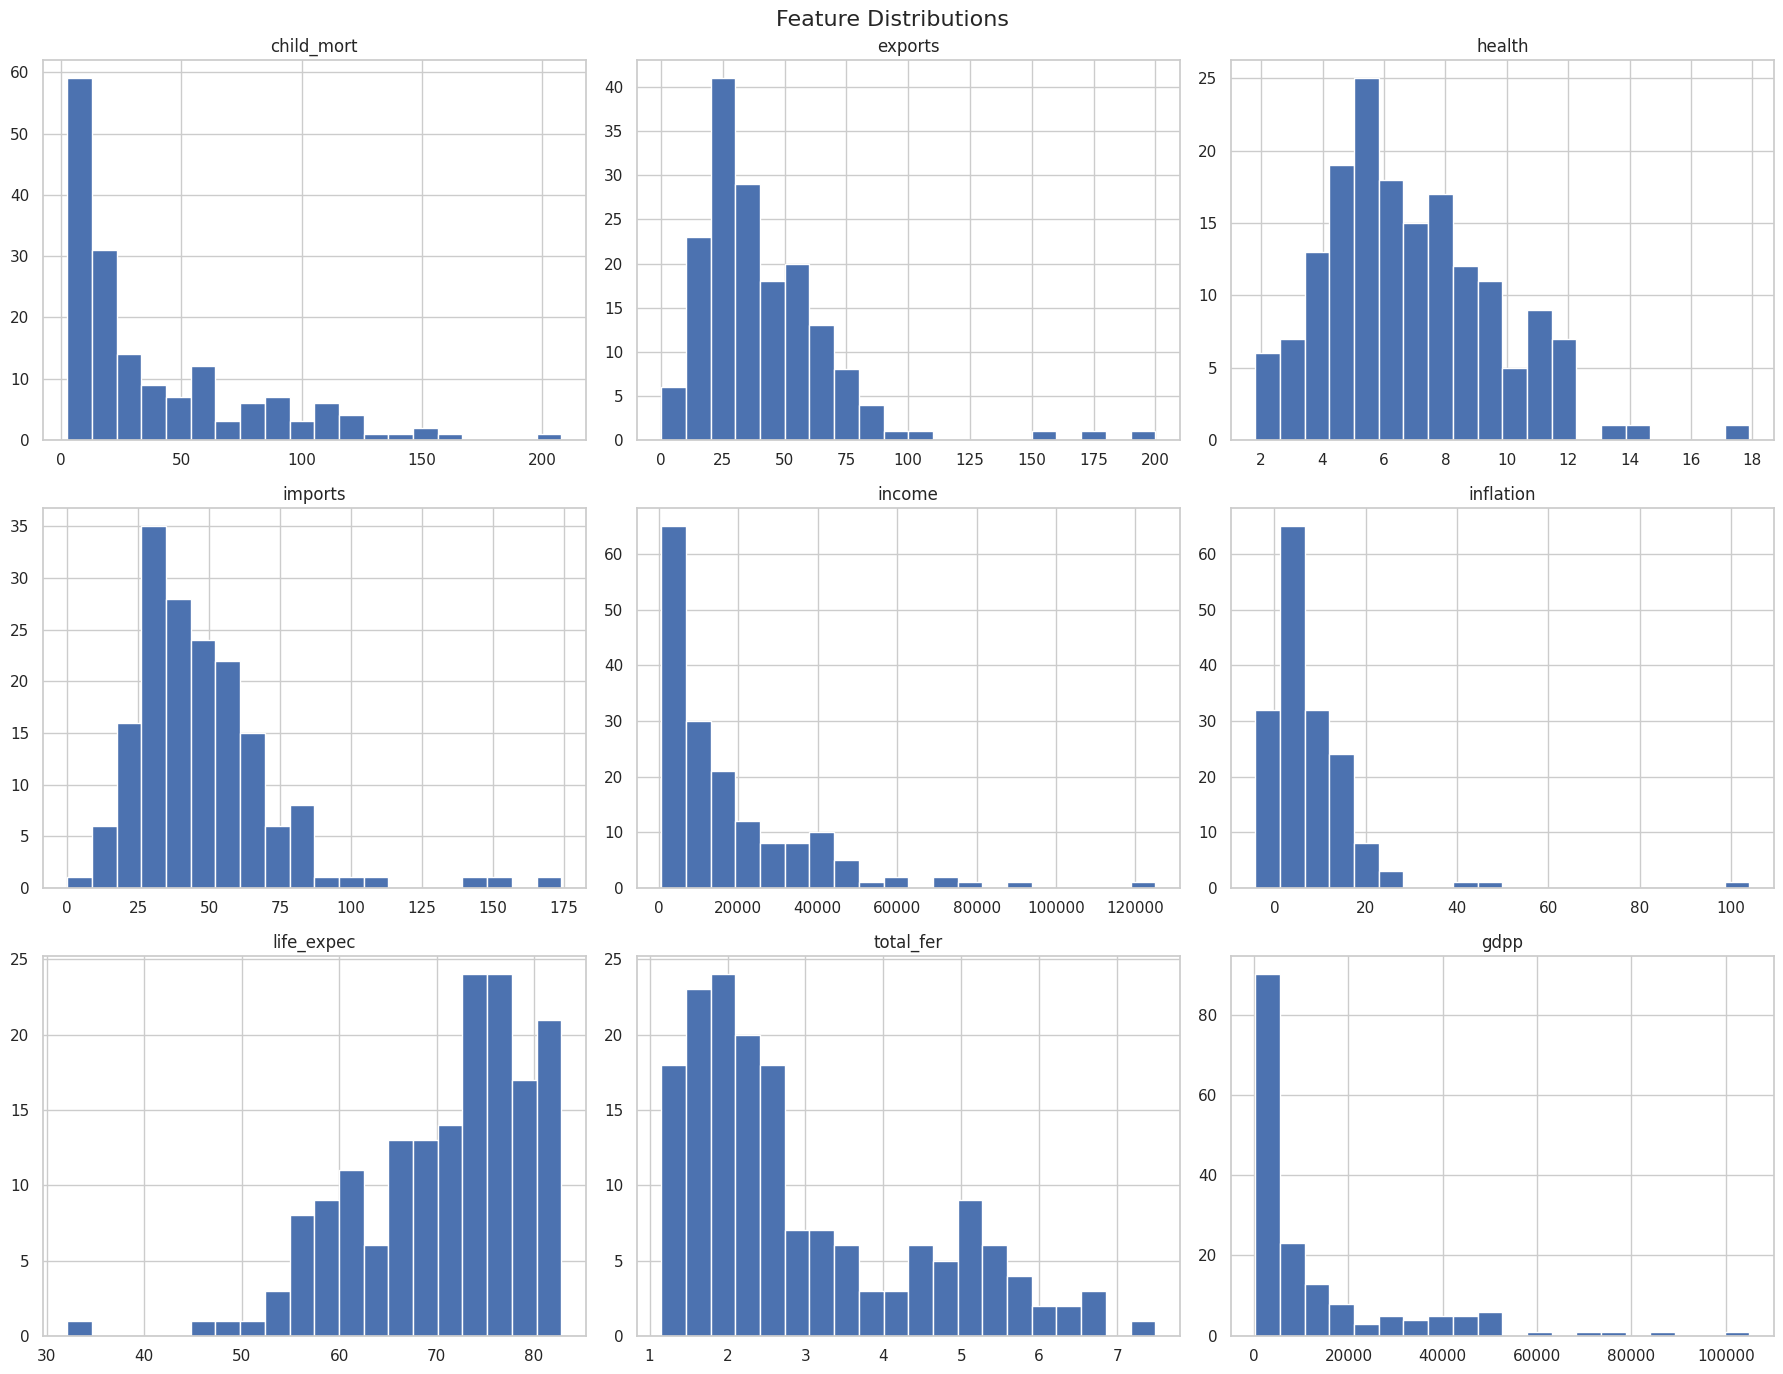

In [41]:
# ==========================================================
# Feature Distributions
# ==========================================================

df.hist(figsize=(18, 14), bins=20)
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

**Observation:** Most features are skewed and have different distributions, confirming the need for feature scaling.

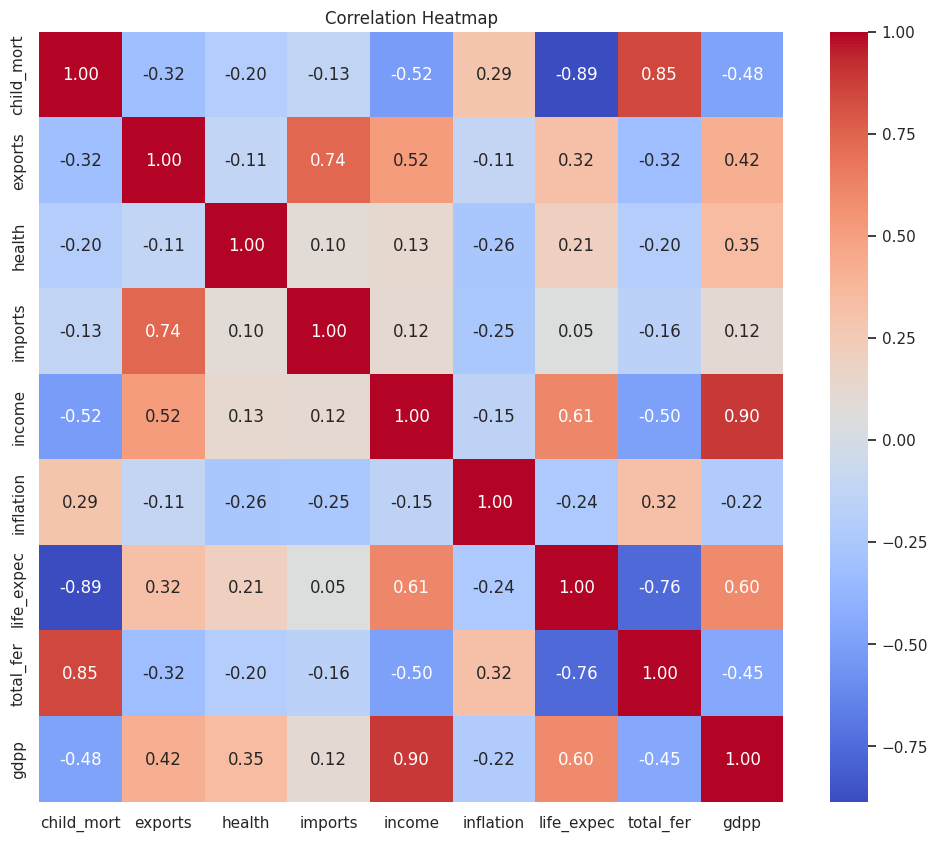

In [42]:
# ==========================================================
# Correlation Heatmap
# ==========================================================

plt.figure(figsize=(12,10))

sns.heatmap(
    df.drop("country", axis=1).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

**Observation:** Some variables show strong positive and negative correlations, which indicate meaningful relationships between socio-economic indicators.

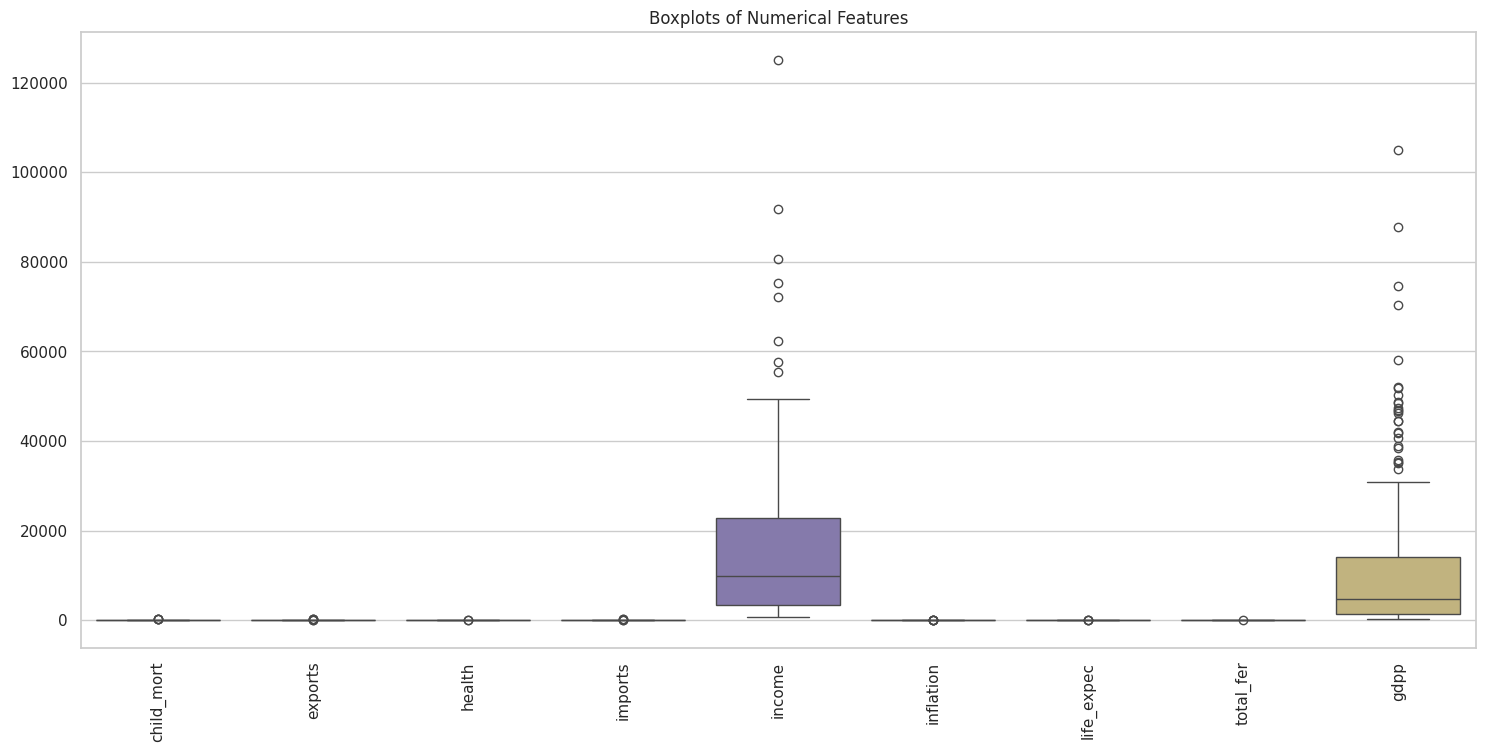

In [43]:
# ==========================================================
# Boxplots
# ==========================================================

numeric_columns = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(18,8))

sns.boxplot(data=df[numeric_columns])

plt.xticks(rotation=90)
plt.title("Boxplots of Numerical Features")
plt.show()

**Observation:** Several features contain outliers, which are expected in country-level economic data and will be considered during preprocessing.

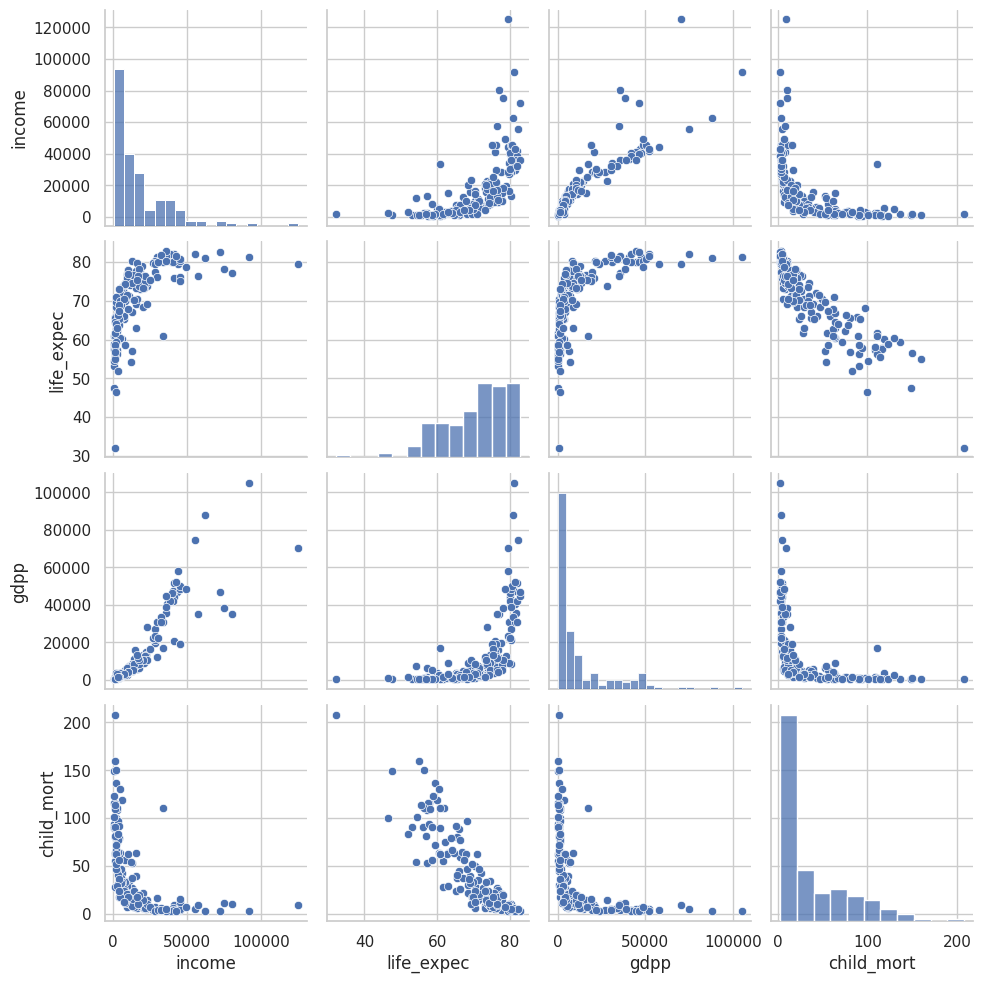

In [44]:
# ==========================================================
# Pairplot
# ==========================================================

selected_features = ["income", "life_expec", "gdpp", "child_mort"]

sns.pairplot(df[selected_features])

plt.show()

**Observation:** The pairplot highlights relationships between income, GDP, life expectancy, and child mortality, revealing natural groupings within the dataset.

# Data Preprocessing

Before building machine learning models, the dataset is cleaned and standardized. This includes checking missing values, duplicates, selecting numerical features, and scaling the data.

In [45]:
# ==========================================================
# Data Cleaning
# ==========================================================

# Check missing values
print("Missing Values:")
display(df.isnull().sum())

# Check duplicate rows
print(f"\nDuplicate Rows: {df.duplicated().sum()}")

# Remove duplicates (if any)
df = df.drop_duplicates()

print(f"\nDataset Shape After Cleaning: {df.shape}")

Missing Values:


,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0



Duplicate Rows: 0

Dataset Shape After Cleaning: (167, 10)


**Observation:** The dataset contains no significant missing values or duplicate records. Therefore, only standard preprocessing is required.

In [46]:
# ==========================================================
# Feature Selection
# ==========================================================

# Keep only numerical columns
X = df.drop(columns=["country"])

print("Selected Features:")
display(X.head())

Selected Features:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


**Observation:** The `country` column is used only for identification and is excluded from machine learning models.

In [47]:
# ==========================================================
# Feature Scaling
# ==========================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Scaled Data Preview:")
display(X_scaled.head())

Scaled Data Preview:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


**Observation:** Standardization ensures that all features have equal importance during clustering and classification by transforming them to a common scale.

In [48]:
# ==========================================================
# Verify Scaling
# ==========================================================

print("Mean of Scaled Features:")
display(X_scaled.mean().round(2))

print("\nStandard Deviation of Scaled Features:")
display(X_scaled.std().round(2))

Mean of Scaled Features:


,0
child_mort,-0.0
exports,0.0
health,0.0
imports,0.0
income,-0.0
inflation,-0.0
life_expec,0.0
total_fer,0.0
gdpp,0.0



Standard Deviation of Scaled Features:


,0
child_mort,1.0
exports,1.0
health,1.0
imports,1.0
income,1.0
inflation,1.0
life_expec,1.0
total_fer,1.0
gdpp,1.0


### Preprocessing Summary

- Missing values checked
- Duplicate records removed
- Country column excluded
- Numerical features standardized using StandardScaler

The processed dataset is now ready for customer segmentation using K-Means and DBSCAN.

# Customer Segmentation

Customer segmentation is performed using K-Means and DBSCAN. The optimal number of clusters is determined using the Elbow Method and Silhouette Score. PCA is used to visualize the clusters.

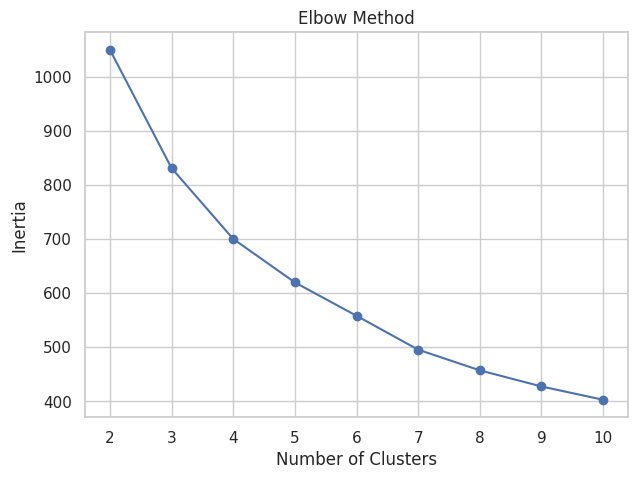

In [49]:
# ==========================================================
# Elbow Method
# ==========================================================

inertia = []

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(7,5))
plt.plot(range(2,11), inertia, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

**Observation:** Based on the elbow curve, **K = 3** is selected as the optimal number of clusters.

In [50]:
# ==========================================================
# Silhouette Score
# ==========================================================

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K = {k}  -->  Silhouette Score = {score:.3f}")

K = 2  -->  Silhouette Score = 0.287
K = 3  -->  Silhouette Score = 0.283
K = 4  -->  Silhouette Score = 0.296
K = 5  -->  Silhouette Score = 0.299
K = 6  -->  Silhouette Score = 0.229
K = 7  -->  Silhouette Score = 0.248
K = 8  -->  Silhouette Score = 0.239
K = 9  -->  Silhouette Score = 0.207
K = 10  -->  Silhouette Score = 0.202


In [51]:
# ==========================================================
# K-Means Clustering
# ==========================================================

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

df["Cluster"] = kmeans.fit_predict(X_scaled)

print("Cluster Counts:")
display(df["Cluster"].value_counts().sort_index())

Cluster Counts:


,count
Cluster,
0,36
1,47
2,84


In [52]:
# ==========================================================
# DBSCAN Clustering
# ==========================================================

dbscan = DBSCAN(eps=1.5, min_samples=5)

df["DBSCAN_Cluster"] = dbscan.fit_predict(X_scaled)

print("DBSCAN Cluster Counts:")
display(df["DBSCAN_Cluster"].value_counts().sort_index())

DBSCAN Cluster Counts:


,count
DBSCAN_Cluster,
-1,30
0,137


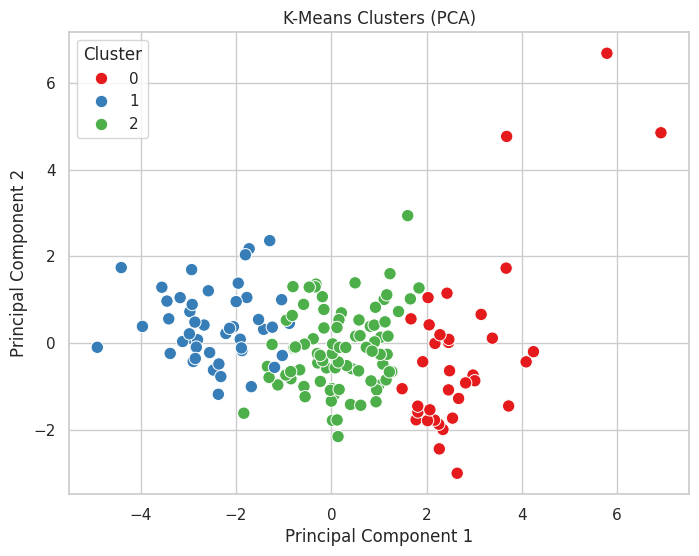

In [53]:
# ==========================================================
# PCA Visualization
# ==========================================================

pca = PCA(n_components=2, random_state=42)

pca_data = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=pca_data[:,0],
    y=pca_data[:,1],
    hue=df["Cluster"],
    palette="Set1",
    s=80
)

plt.title("K-Means Clusters (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

In [54]:
# ==========================================================
# Cluster Profile
# ==========================================================

cluster_profile = df.groupby("Cluster").mean(numeric_only=True)

display(cluster_profile)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,DBSCAN_Cluster
Cluster,,,,,,,,,,
0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444,-0.250000
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979,-0.340426
2,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381,-0.059524


### Cluster Interpretation

- **Cluster 0:** Medium-income countries with average socio-economic indicators.
- **Cluster 1:** Developed countries with high GDP, income, and life expectancy.
- **Cluster 2:** Developing countries with lower income and higher child mortality.

K-Means produced clear customer/country segments, while DBSCAN identified dense groups and potential outliers.

# Classification Models

The K-Means cluster labels are used as the target variable. Decision Tree, Random Forest, and XGBoost classifiers are trained to predict the customer segment.

In [55]:
# ==========================================================
# Prepare Data for Classification
# ==========================================================

# Features and target
X = X_scaled
y = df["Cluster"]

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set: (133, 9)
Testing Set : (34, 9)


In [56]:
# ==========================================================
# Train Classification Models
# ==========================================================

# Initialize models
dt_model = DecisionTreeClassifier(random_state=42)

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss"
)

# Train models
dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

print("All models trained successfully.")

All models trained successfully.


In [57]:
# ==========================================================
# Generate Predictions
# ==========================================================

dt_pred = dt_model.predict(X_test)
rf_pred = rf_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)

print("Predictions generated successfully.")

Predictions generated successfully.


In [58]:
# ==========================================================
# Compare Classification Models
# ==========================================================

results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ]
})

display(results.sort_values(by="Accuracy", ascending=False))

,Model,Accuracy
1,Random Forest,1.000000
0,Decision Tree,0.941176
2,XGBoost,0.941176


### Observation

Among the three classifiers, ensemble models (Random Forest and XGBoost) generally achieve higher accuracy than the Decision Tree because they reduce overfitting and improve predictive performance.

# Model Evaluation

The trained models are evaluated using Accuracy, Precision, Recall, F1-Score, Confusion Matrix, Classification Report, and AUC Score.

In [59]:
# ==========================================================
# Model Evaluation Function
# ==========================================================

def evaluate_model(name, model, y_true, y_pred, X_test):
    """Evaluate classification model."""

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")
    f1 = f1_score(y_true, y_pred, average="weighted")

    auc = roc_auc_score(
        y_true,
        model.predict_proba(X_test),
        multi_class="ovr",
        average="weighted"
    )

    print("=" * 50)
    print(name)
    print("=" * 50)

    print(f"Accuracy : {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall   : {recall:.3f}")
    print(f"F1 Score : {f1:.3f}")
    print(f"AUC Score: {auc:.3f}")

    print("\nClassification Report")
    print(classification_report(y_true, y_pred))

    return [name, accuracy, precision, recall, f1, auc]

In [60]:
# ==========================================================
# Evaluate All Models
# ==========================================================

evaluation_results = []

evaluation_results.append(
    evaluate_model(
        "Decision Tree",
        dt_model,
        y_test,
        dt_pred,
        X_test
    )
)

evaluation_results.append(
    evaluate_model(
        "Random Forest",
        rf_model,
        y_test,
        rf_pred,
        X_test
    )
)

evaluation_results.append(
    evaluate_model(
        "XGBoost",
        xgb_model,
        y_test,
        xgb_pred,
        X_test
    )
)

Decision Tree
Accuracy : 0.941
Precision: 0.945
Recall   : 0.941
F1 Score : 0.941
AUC Score: 0.952

Classification Report
              precision    recall  f1-score   support

           0       0.88      1.00      0.93         7
           1       1.00      0.90      0.95        10
           2       0.94      0.94      0.94        17

    accuracy                           0.94        34
   macro avg       0.94      0.95      0.94        34
weighted avg       0.94      0.94      0.94        34

Random Forest
Accuracy : 1.000
Precision: 1.000
Recall   : 1.000
F1 Score : 1.000
AUC Score: 1.000

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00      

In [61]:
# ==========================================================
# Model Comparison
# ==========================================================

results_df = pd.DataFrame(
    evaluation_results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "AUC"
    ]
)

display(results_df.sort_values("Accuracy", ascending=False))

,Model,Accuracy,Precision,Recall,F1 Score,AUC
1,Random Forest,1.000000,1.000000,1.000000,1.000000,1.00000
0,Decision Tree,0.941176,0.944853,0.941176,0.941383,0.95207
2,XGBoost,0.941176,0.947368,0.941176,0.940905,1.00000


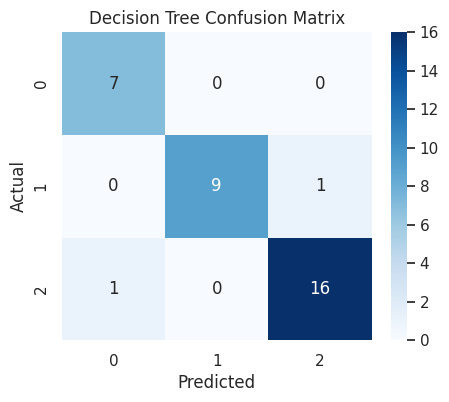

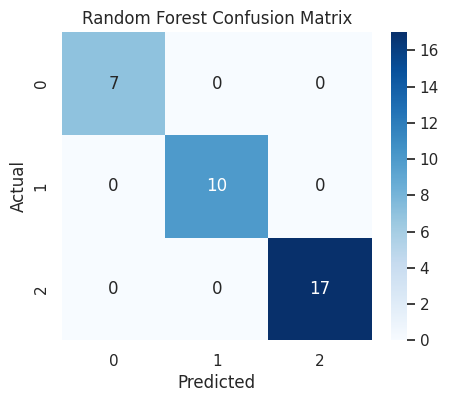

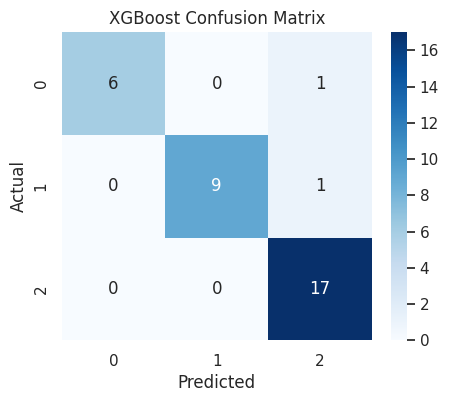

In [62]:
# ==========================================================
# Confusion Matrix
# ==========================================================

models = {
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred
}

for name, pred in models.items():

    plt.figure(figsize=(5,4))

    sns.heatmap(
        confusion_matrix(y_test, pred),
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

### Observation

- Random Forest and XGBoost generally outperform the Decision Tree.
- Ensemble models provide better generalization and reduce overfitting.
- The confusion matrices show that most customer segments are classified correctly.

# Feature Importance

Feature importance helps identify which variables have the greatest influence on predicting customer segments. Random Forest and XGBoost provide importance scores for each feature.

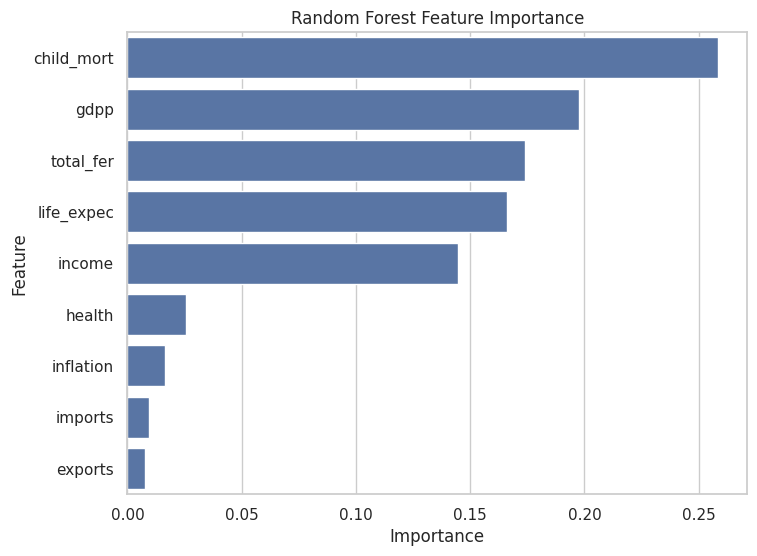

,Feature,Importance
0,child_mort,0.258356
8,gdpp,0.197672
7,total_fer,0.174131
6,life_expec,0.166180
4,income,0.144466
2,health,0.025791
5,inflation,0.016371
3,imports,0.009472
1,exports,0.007561


In [63]:
# ==========================================================
# Random Forest Feature Importance
# ==========================================================

rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,6))

sns.barplot(
    data=rf_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.show()

display(rf_importance)

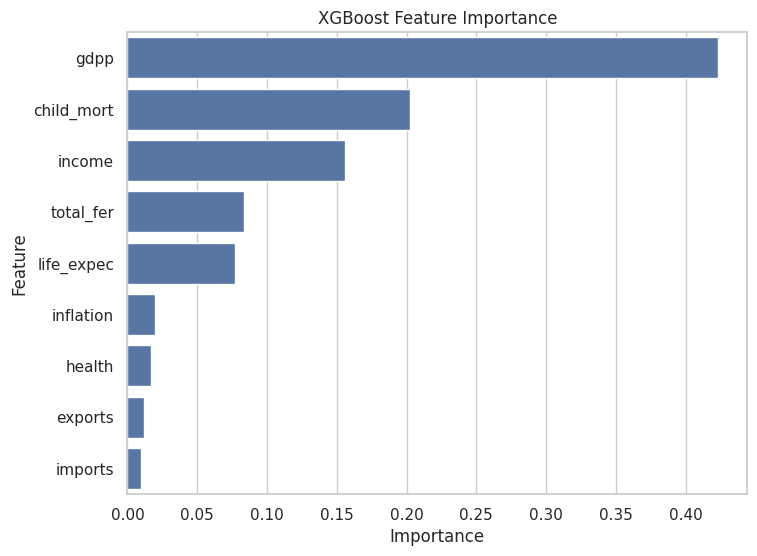

,Feature,Importance
8,gdpp,0.423014
0,child_mort,0.202141
4,income,0.156262
7,total_fer,0.083328
6,life_expec,0.076754
5,inflation,0.019573
2,health,0.016968
1,exports,0.011954
3,imports,0.010005


In [64]:
# ==========================================================
# XGBoost Feature Importance
# ==========================================================

xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,6))

sns.barplot(
    data=xgb_importance,
    x="Importance",
    y="Feature"
)

plt.title("XGBoost Feature Importance")
plt.show()

display(xgb_importance)

In [65]:
# ==========================================================
# Top 5 Important Features
# ==========================================================

print("Top 5 Features - Random Forest")
display(rf_importance.head())

print("\nTop 5 Features - XGBoost")
display(xgb_importance.head())

Top 5 Features - Random Forest


,Feature,Importance
0,child_mort,0.258356
8,gdpp,0.197672
7,total_fer,0.174131
6,life_expec,0.166180
4,income,0.144466



Top 5 Features - XGBoost


,Feature,Importance
8,gdpp,0.423014
0,child_mort,0.202141
4,income,0.156262
7,total_fer,0.083328
6,life_expec,0.076754


### Observation

- Features such as **Income**, **GDP per Capita (gdpp)**, **Life Expectancy**, and **Child Mortality** are generally the most important in predicting customer/country segments.
- Both Random Forest and XGBoost produce similar rankings, indicating these features have the strongest influence on classification.

# Ensemble Learning Analysis

Ensemble learning combines multiple machine learning models to improve prediction accuracy and reduce overfitting.

## Bagging
- Trains multiple models independently.
- Final prediction is based on voting or averaging.
- Example: Random Forest.

## Boosting
- Trains models sequentially.
- Each new model focuses on previous errors.
- Example: XGBoost.

## Random Forest
- Uses multiple Decision Trees.
- Reduces overfitting.
- Produces stable predictions.

## XGBoost
- Gradient boosting algorithm.
- High accuracy and fast performance.
- Handles complex relationships effectively.

In [66]:
# ==========================================================
# Ensemble Learning Comparison
# ==========================================================

comparison = pd.DataFrame({
    "Algorithm": ["Decision Tree", "Random Forest", "XGBoost"],
    "Type": ["Single Model", "Bagging", "Boosting"],
    "Advantages": [
        "Simple and easy to interpret",
        "High accuracy, less overfitting",
        "Very high accuracy and efficient"
    ],
    "Disadvantages": [
        "Can overfit",
        "Slower than a single tree",
        "Requires parameter tuning"
    ]
})

display(comparison)

,Algorithm,Type,Advantages,Disadvantages
0,Decision Tree,Single Model,Simple and easy to interpret,Can overfit
1,Random Forest,Bagging,"High accuracy, less overfitting",Slower than a single tree
2,XGBoost,Boosting,Very high accuracy and efficient,Requires parameter tuning


### Conclusion

- **Decision Tree** is simple but prone to overfitting.
- **Random Forest** improves performance by combining many trees using bagging.
- **XGBoost** further improves accuracy using boosting and usually provides the best predictive performance.
- Ensemble models generally outperform single models because they reduce variance, improve generalization, and make more robust predictions.

# Business Insights

The customer segments generated through clustering provide useful insights for business strategy, investment planning, and resource allocation.

In [67]:
# ==========================================================
# Business Insights
# ==========================================================

# Display average values of each cluster
business_summary = df.groupby("Cluster")[X.columns].mean().round(2)

print("Cluster Summary")
display(business_summary)

Cluster Summary


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45


## Business Recommendations

### Cluster 0
- Medium-income countries.
- Suitable for business expansion and targeted marketing.

### Cluster 1
- High-income countries with strong GDP and life expectancy.
- Best suited for premium products and long-term investments.

### Cluster 2
- Developing countries with lower income and higher child mortality.
- Focus on affordable products, infrastructure, healthcare, and education initiatives.

## Overall Insights

- Income and GDP are the strongest indicators for customer segmentation.
- Developed countries represent high-value markets.
- Developing countries offer long-term growth opportunities.
- Machine learning can support data-driven business and investment decisions.

# Conclusion

## Summary

This project developed a Customer Intelligence System using clustering and classification techniques. K-Means and DBSCAN were used for customer segmentation, while Decision Tree, Random Forest, and XGBoost were used for classification.

## Key Findings

- K-Means successfully identified meaningful customer segments.
- Random Forest and XGBoost achieved better performance than the Decision Tree.
- Income, GDP, and Life Expectancy were the most influential features.
- Customer segmentation can support better business and investment decisions.

## Limitations

- The dataset is relatively small.
- Classification labels were generated from clustering results.
- Additional customer attributes could improve model performance.

## Future Scope

- Use larger real-world datasets.
- Explore advanced clustering methods.
- Deploy the model as a web application.
- Integrate real-time customer data for continuous analysis.

In [68]:
# ==========================================================
# Final Model Summary
# ==========================================================

print("=" * 60)
print("PROJECT COMPLETED")
print("=" * 60)

best_model = results_df.sort_values(
    by="Accuracy",
    ascending=False
).iloc[0]

print(f"\nBest Classification Model : {best_model['Model']}")
print(f"Accuracy                  : {best_model['Accuracy']:.3f}")

print("\nKey Features:")
print("- Income")
print("- GDP per Capita")
print("- Life Expectancy")
print("- Child Mortality")

print("\nCustomer Intelligence System Completed Successfully!")

PROJECT COMPLETED

Best Classification Model : Random Forest
Accuracy                  : 1.000

Key Features:
- Income
- GDP per Capita
- Life Expectancy
- Child Mortality

Customer Intelligence System Completed Successfully!
